# Dataset inventado

In [2]:
import pandas as pd
import numpy as np

np.random.seed(0)

n = 200

df = pd.DataFrame({
    "fecha": pd.date_range(start="2023-01-01", periods=n, freq="D"),
    "pais": np.random.choice(["Argentina", "Chile", "Uruguay"], n),
    "categoria": np.random.choice(["Electronics", "Clothing", "Food"], n),
    "ventas": np.random.randint(100, 1000, n),
    "clientes": np.random.randint(1, 50, n)
})

df.head()

,fecha,pais,categoria,ventas,clientes
0,2023-01-01,Argentina,Electronics,849,37
1,2023-01-02,Chile,Food,763,32
2,2023-01-03,Argentina,Food,380,30
3,2023-01-04,Chile,Electronics,104,47
4,2023-01-05,Chile,Food,712,30


# Data wrangling

In [3]:
df.head()

,fecha,pais,categoria,ventas,clientes
0,2023-01-01,Argentina,Electronics,849,37
1,2023-01-02,Chile,Food,763,32
2,2023-01-03,Argentina,Food,380,30
3,2023-01-04,Chile,Electronics,104,47
4,2023-01-05,Chile,Food,712,30



- Creacion de nueva columna 'ventas_por_clientes'
- Extraccion de mes y fecha





In [4]:
df["ventas_x_cliente"] = df["ventas"] / df["clientes"]
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day

# Analisis con **Pandas**


1.   Ventas promedio por pais
2.   Total de ventas por categoria
3. Ventas por pais y categoria
4. promedio de ventas por mes
5. top 3 dias con mas ventas
6. categoria con mayor   'ventas_por_cliente' promedio












In [5]:
df.groupby('pais')['ventas'].mean()
df.groupby('categoria')['ventas'].sum()


,ventas
categoria,
Clothing,40213
Electronics,35567
Food,35977


In [6]:
df.groupby(['pais','categoria'])['ventas'].sum()
df.groupby('mes')['ventas'].mean()

,ventas
mes,
1,580.161290
2,567.142857
3,555.387097
4,487.933333
5,586.129032
6,579.500000
7,551.684211


In [7]:
df.groupby('dia')['ventas'].max(3).idxmax()
df.groupby('categoria')['ventas_x_cliente'].agg('max','mean').reset_index()

,categoria,ventas_x_cliente
0,Clothing,781.0
1,Electronics,471.0
2,Food,618.0


# Visualizacion
Uso de MatPlotLib


# Insights

El pais que mas vende es Uruguay
La categoria mas rentables es Electronics


<Axes: xlabel='mes'>

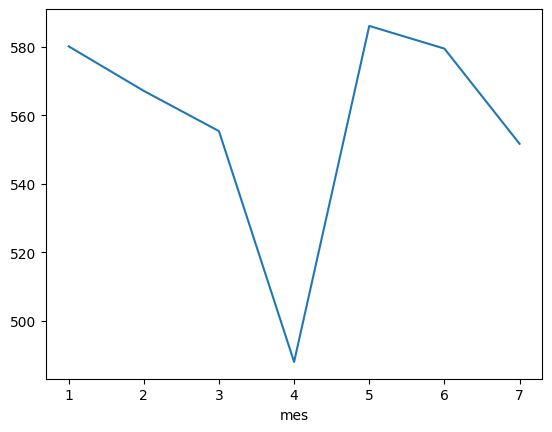

In [8]:
Pais_mas_vendedor = df.groupby('pais')['ventas'].max().idxmax()
print(f'El pais que mas vende es {Pais_mas_vendedor}')
Categoria_mas_rentable = df.groupby('categoria')['ventas'].max().idxmax()
print(f'La categoria mas rentables es {Categoria_mas_rentable}')
ventas_por_mes = df.groupby('mes')['ventas'].mean()
ventas_por_mes.plot(kind="line")

Viendo la grafica de las ventas por mes se puede apreciar que no son uniformes, eso se deebe a que el dataset fue creado con **valores aleatorios**

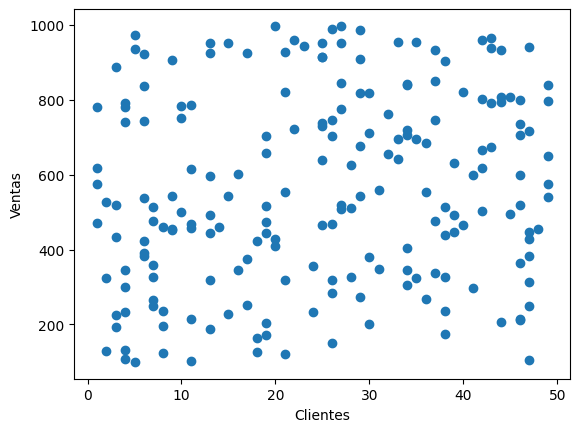

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df["clientes"], df["ventas"])
plt.xlabel("Clientes")
plt.ylabel("Ventas")
plt.show()

In [11]:
print(df['clientes'].corr(df['ventas']))

0.1716510952832984


In [ ]:
import seaborn as sns

sns.regplot(x="clientes", y="ventas", data=df)


**Correlacion entre clientes y ventas**

Si la correlación ≈ 0 → no hay relación
Si es positiva → más clientes = más ventas
Si es negativa → raro, pero posible.
AL ser un dataset aleatorio y sin logica de negocio real, tiene sentido que el grafico de dispersion no devuelva ninguna relacion.